In [78]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score


In [2]:
df = pd.read_csv("shop_smart_ecommerce (1).csv")

In [111]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  int64  
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [112]:
num_features = df.select_dtypes(include=["int64", "float64"]).columns
cat_features =df.select_dtypes(include=["object", "category"]).columns


In [113]:
# feature selection
feature = ["ProductRelated_Duration","BounceRates","Informational_Duration","PageValues","SpecialDay","Month"
           ,"TrafficType","VisitorType","Weekend"]
target = ["Revenue"]

In [106]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["SpecialDay"] = le.fit_transform(df["SpecialDay"])
df["Month"] = le.fit_transform(df["Month"])
df["TrafficType"] = le.fit_transform(df["TrafficType"])
df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Weekend"] = le.fit_transform(df["Weekend"])


In [107]:
df.head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0,2,1,1,1,0,2,0,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0,2,2,2,1,1,2,0,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0,2,4,1,9,2,2,0,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0,2,3,2,2,3,2,0,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0,2,3,3,1,3,2,1,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0,2,2,2,1,2,2,0,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,2,2,2,4,3,2,2,0,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0,2,1,2,1,4,2,1,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,4,2,2,2,2,2,2,0,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,2,2,2,4,1,1,2,0,False


In [108]:
X = df[feature]
y = df[target]

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

In [110]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [102]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

score = f1_score(y_test, y_pred)
print("f1_Score :",score)

accuracy:  0.8569883752365505
f1_Score : 0.5474764756201882


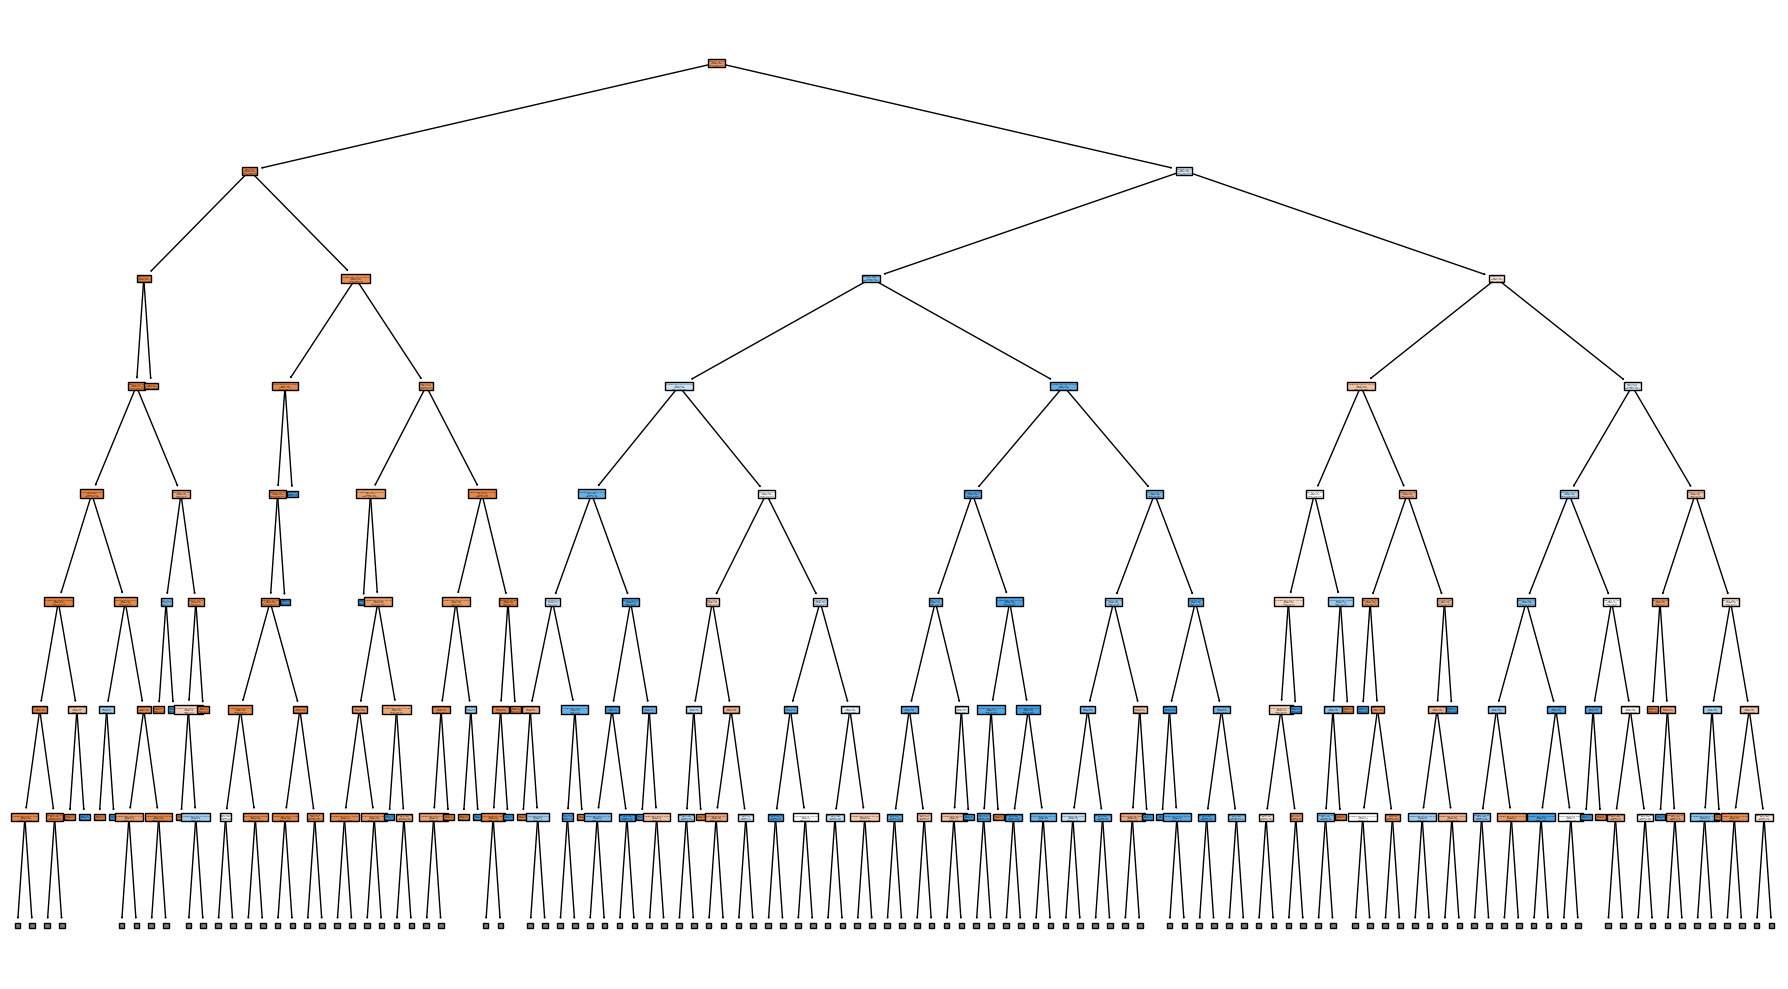

In [103]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    class_names=["no", "yes"],
    max_depth=7
)

plt.tight_layout()
plt.show()

# Decision Tree with pre-pruning

In [104]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

    if depth==4:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["no", "yes"],
            filled=True
        
        
        plt.tight_layout()
        plt.show()

SyntaxError: '(' was never closed (2269800772.py, line 12)

In [ ]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["no", "yes"],
            filled=True
        )
        
        plt.tight_layout()
        plt.show()

# Decision Tree With Post_Pruning

In [ ]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

In [95]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 3.86204766e-05 3.86204766e-05 3.86204766e-05
 4.41376875e-05 4.41376875e-05 5.37928067e-05 5.57851328e-05
 5.73144307e-05 5.73395851e-05 6.36101967e-05 6.62065313e-05
 6.86586250e-05 7.17237422e-05 7.20915563e-05 7.24133936e-05
 7.43801771e-05 7.48271734e-05 7.50340688e-05 7.51533598e-05
 7.54018828e-05 7.55618020e-05 7.68020841e-05 7.68365503e-05
 7.72409532e-05 7.72409532e-05 7.72409532e-05 7.99963842e-05
 8.68960723e-05 8.68960723e-05 8.68960723e-05 8.68960723e-05
 9.26891438e-05 9.26891438e-05 9.26891438e-05 9.26891438e-05
 9.26891438e-05 9.26891438e-05 9.30079700e-05 9.62519212e-05
 9.65511914e-05 9.65511914e-05 9.65511914e-05 9.65511914e-05
 9.65511914e-05 9.65511914e-05 9.65511914e-05 9.80365944e-05
 9.80365944e-05 9.93097969e-05 9.93097969e-05 9.93097969e-05
 9.93097969e-05 9.93097969e-05 9.93097969e-05 9.93097969e-05
 1.01378751e-04 1.01378751e-04 1.02987938e-04 1.02987938e-04
 1.02987938e-04 1.02987938e-04 1.02987938e-04 1.02987938e-04
 1.02987938e-04 1.031294

In [73]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    trees.append((model, alpha))

In [74]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [75]:
best_acc

0.895647472289808

In [76]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0004494142283872071), max_depth=4)

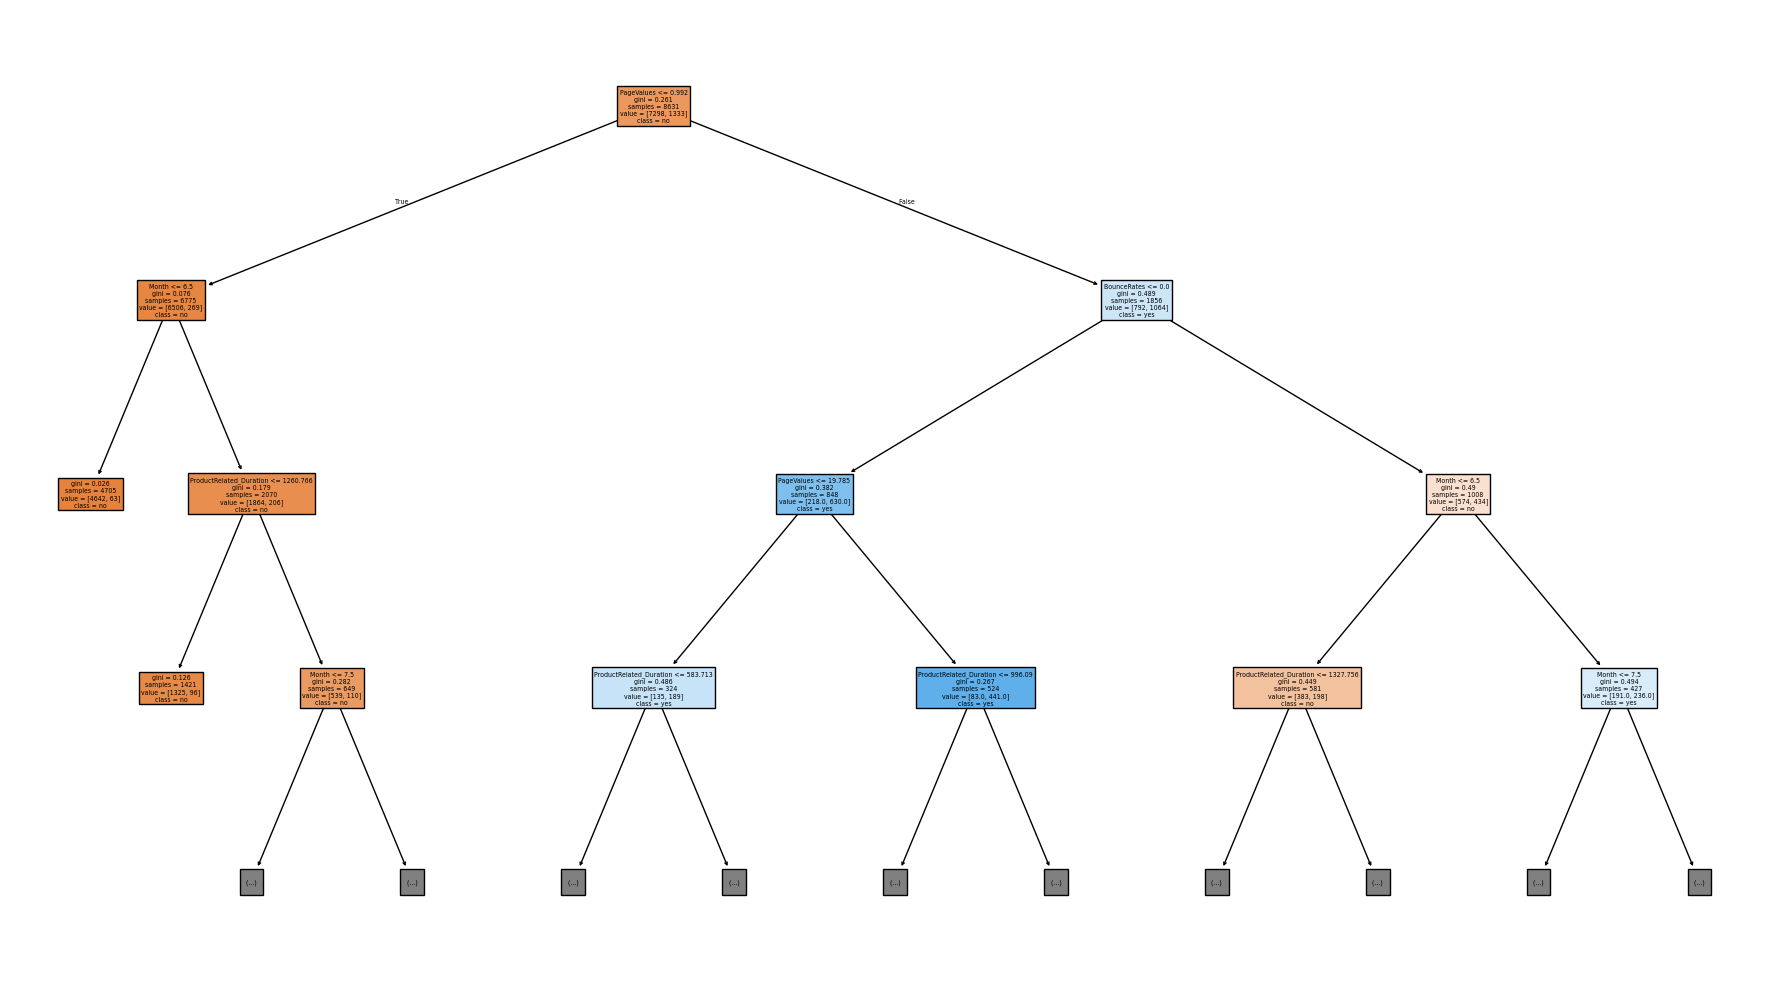

In [77]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["no", "yes"],
    max_depth = 3,
    filled=True
)
        
plt.tight_layout()
plt.show()

In [56]:
print(best_model.score(X_test, y_test))

0.8921330089213301
